# Golf Performance Analyzer

## Project Overview

The goal of this project is to analyze golf performances across
multiple rounds and identify trends and mishaps to figure out where 
my golf game needs the most improvement

The current dataset contains 39 golf rounds consisting of both
9-hole and 18-hole rounds. The data includes scoring, ball striking,
putting, short-game performance, penalties, birdies, handicap, and
round date, this is my very own data, but this analysis can be done
with different sets of golf data, consisting of the same structured data
collection.

The analysis will use Python and data science techniques to evaluate
performance over time and identify areas of strength and weakness.

## Import Libraries/Set-Up Data

The following Python libraries (Pandas, Numpy, MatPlotLib) will be used to 
clean and manage data, creating an visual analysis for reference

Data has been loaded through a csv into a Pandas dataframe

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

golfdatadf = pd.read_csv("../Data/GolfData.csv")

In [3]:
golfdatadf.head()

,Round,Score,Fairways hit %,GIR %,Putts,Up-and-down %,Penalties,3-putt,Birdies,Course Handicap,Holes,Date
0,1.0,84.0,21.40%,55.56%,34.0,16.67%,2.0,1.0,2.0,68.7,18.0,6/15/2025
1,2.0,84.0,35.70%,38.90%,32.0,40.00%,2.0,1.0,2.0,70.5,18.0,6/19/2025
2,3.0,75.0,21.40%,61.10%,29.0,50.00%,2.0,0.0,2.0,69.7,18.0,6/20/2025
3,4.0,78.0,35.70%,38.90%,29.0,60.00%,2.0,0.0,1.0,70.5,18.0,6/24/2025
4,5.0,74.0,57.10%,50.00%,29.0,75.00%,0.0,1.0,1.0,69.8,18.0,7/16/2025


## Initial Observations

The data contains 39 rounds and has a lot of variability in the data, seen 
through the standard deviations, which may help figure out what patterns cause
higher scores.

There are 9 columns that cover multiple sides of golf, which aid in analysis from the
tee to the green, which can help me figure out how I can perform better, letting
me know what to practice on. I have also included dates to show trends of better 
performance across months.

# Data Cleaning

I am cleaning the data I have, making sure everything is to standard so I can make
visualizations. I am making sure every single column has the right type to make calculations and
cleaning the date so it functions properly.


In [4]:
golfdatadf.isnull().sum()
golfdatadf = golfdatadf[0:39]

golfdatadf.info()
golfdatadf["Date"] = pd.to_datetime(golfdatadf["Date"])
golfdatadf["Fairways hit %"] = golfdatadf["Fairways hit %"].str.replace("%", "").astype(float)
golfdatadf["GIR %"] = golfdatadf["GIR %"].str.replace("%", "").astype(float)
golfdatadf["Up-and-down %"] = golfdatadf["Up-and-down %"].str.replace("%", "").astype(float)
golfdatadf.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Round            39 non-null     float64
 1   Score            39 non-null     float64
 2   Fairways hit %   39 non-null     str    
 3   GIR %            39 non-null     str    
 4   Putts            39 non-null     float64
 5   Up-and-down %    39 non-null     str    
 6   Penalties        39 non-null     float64
 7   3-putt           39 non-null     float64
 8   Birdies          39 non-null     float64
 9   Course Handicap  39 non-null     float64
 10  Holes            39 non-null     float64
 11  Date             39 non-null     str    
dtypes: float64(8), str(4)
memory usage: 3.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Round        

In [5]:
golfdatadf[["Putts", "Penalties", "3-putt", "Birdies", "Holes", "Fairways hit %", "GIR %", "Up-and-down %"]].min()
golfdatadf[["Putts", "Penalties", "3-putt", "Birdies", "Holes", "Fairways hit %", "GIR %", "Up-and-down %"]].max()

golfdatadf.duplicated().sum()

golfdatadf = golfdatadf.sort_values("Date")

The data is now cleaned to make sure everything is correct and in the proper range. I sorted it
by date and can now begin an analysis based on scores of 9 holes, 18 holes, and etc.

## Introductory Data Analysis

I am going to do some basic data manipulation and analysis to see how I have performed
over the past years.

The questions I want to ask overall:
How have I been improving over time?
What has the most effect and on my score (correlation)?
What do I need to work on?


In [6]:
golfdatadf["Putts_per_hole"] = golfdatadf["Putts"]/golfdatadf["Holes"]
golfdatadf["Score_per_hole"] = golfdatadf["Score"]/golfdatadf["Holes"]
golfdatadf["CourseHandicap_avg_hole"] = golfdatadf["Course Handicap"]/golfdatadf["Holes"]

I am going to analyze the averages on my scores based on an 18 hole basis, using the difference between the handicap average and the score to find the base number of my performance.

In [7]:
golfdatadf["difference_per_hole"] = golfdatadf["Score_per_hole"] - golfdatadf["CourseHandicap_avg_hole"]
golfdatadf["difference_round"] = golfdatadf["difference_per_hole"] * 18

golfdatadf["difference_round"].mean()
golfdatadf["CourseHandicap_avg_hole"].mean() * 18

np.float64(70.29487179487178)

The difference per round metric average 7.961538461538463, means that I am hitting around 8 strokes past the course handicap per round, based on a 70.29487179487178 average course handicap, which means I average about 78.25 for a round.

I will now average as much as I can, and create a summary to understand my averages per round
(adjusting for holes)

In [8]:
summary = {
    "Average Fairway %": golfdatadf["Fairways hit %"].mean().__round__(3),
    "Average GIR %": golfdatadf["GIR %"].mean().__round__(3),
    "Average Up-and-down %": golfdatadf["Up-and-down %"].mean().__round__(3),
    "Average Penalties": golfdatadf["Penalties"].mean().__round__(3),
    "Average 3-putt": golfdatadf["3-putt"].mean().__round__(3),
    "Average Birdies": golfdatadf["Birdies"].mean().__round__(3),
}

summary

{'Average Fairway %': np.float64(39.533),
 'Average GIR %': np.float64(50.707),
 'Average Up-and-down %': np.float64(42.917),
 'Average Penalties': np.float64(1.231),
 'Average 3-putt': np.float64(0.872),
 'Average Birdies': np.float64(1.487)}

My averages do not appear that bad, but I would like to compare them in terms of time, and figure 
out how I score, comparing the relationships of variables.

## Exploratory Data Analysis

I am going to create visualizations to help structure the relationships and see trends and patterns of my golf game.

### 1. Scoring differential over time

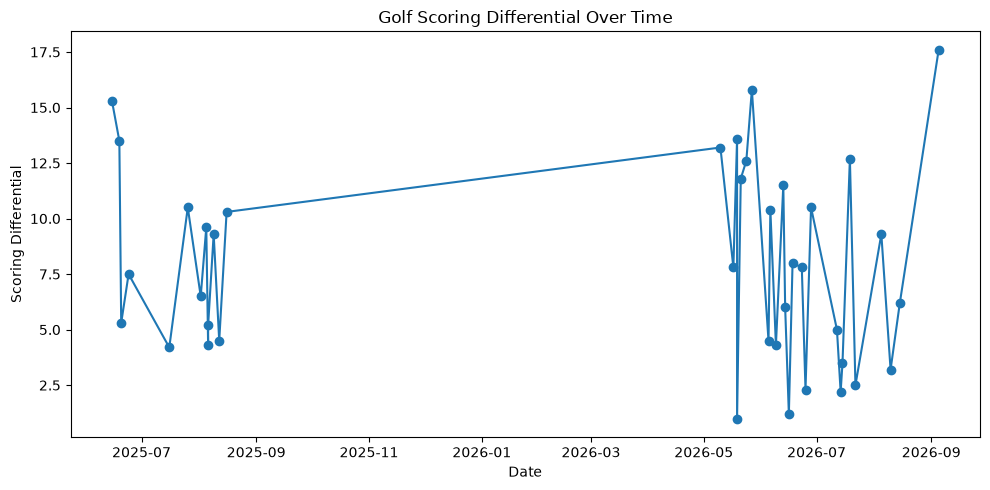

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(golfdatadf["Date"], golfdatadf["difference_round"], marker="o")

plt.xlabel("Date")
plt.ylabel("Scoring Differential")
plt.title("Golf Scoring Differential Over Time")

plt.tight_layout()
plt.show()

The scoring differential is very variable, but that is how golf goes, where you have a good round and then a bad round. There is also not a huge time range, which is a factor into the variability across the y-axis

### 2. GIR/Fairway/Up-and-down/3-putt over time

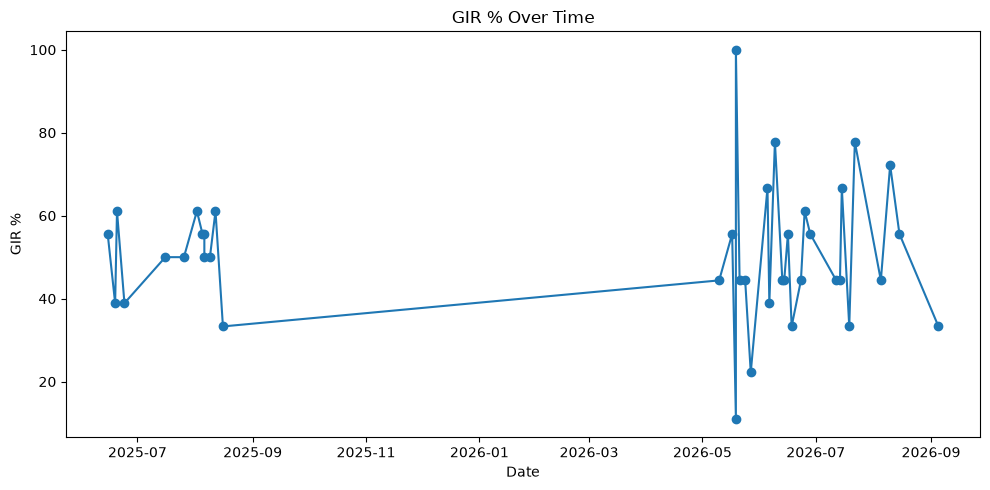

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(golfdatadf["Date"], golfdatadf["GIR %"], marker="o")

plt.xlabel("Date")
plt.ylabel("GIR %")
plt.title("GIR % Over Time")

plt.tight_layout()
plt.show()

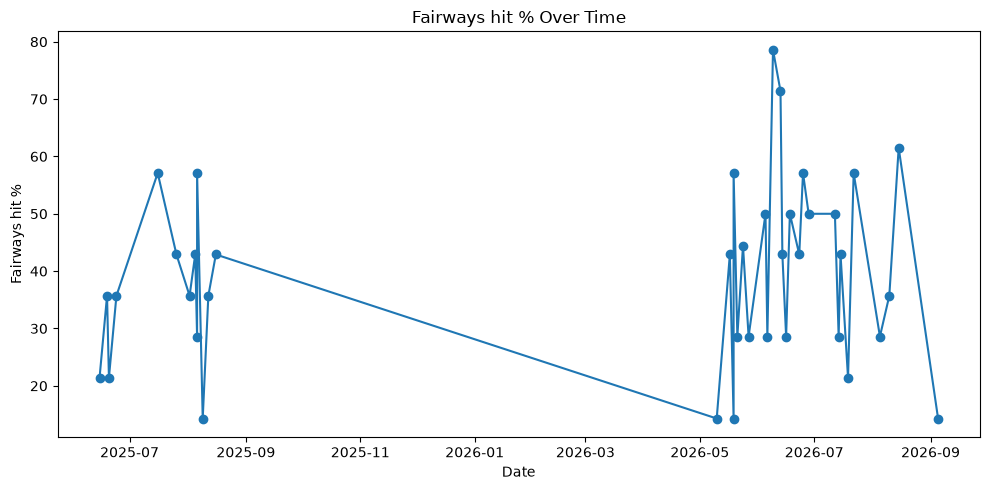

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(golfdatadf["Date"], golfdatadf["Fairways hit %"], marker="o")

plt.xlabel("Date")
plt.ylabel("Fairways hit %")
plt.title("Fairways hit % Over Time")

plt.tight_layout()
plt.show()

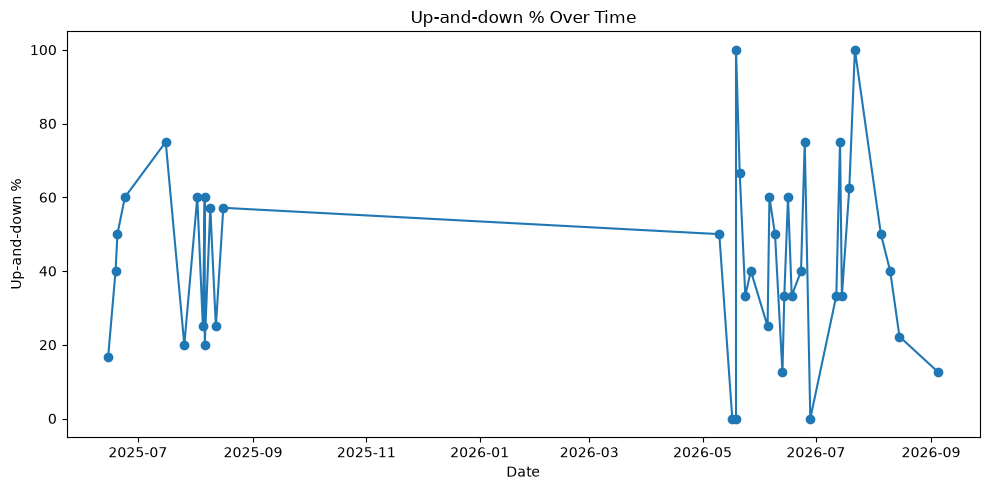

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(golfdatadf["Date"], golfdatadf["Up-and-down %"], marker="o")

plt.xlabel("Date")
plt.ylabel("Up-and-down %")
plt.title("Up-and-down % Over Time")

plt.tight_layout()
plt.show()

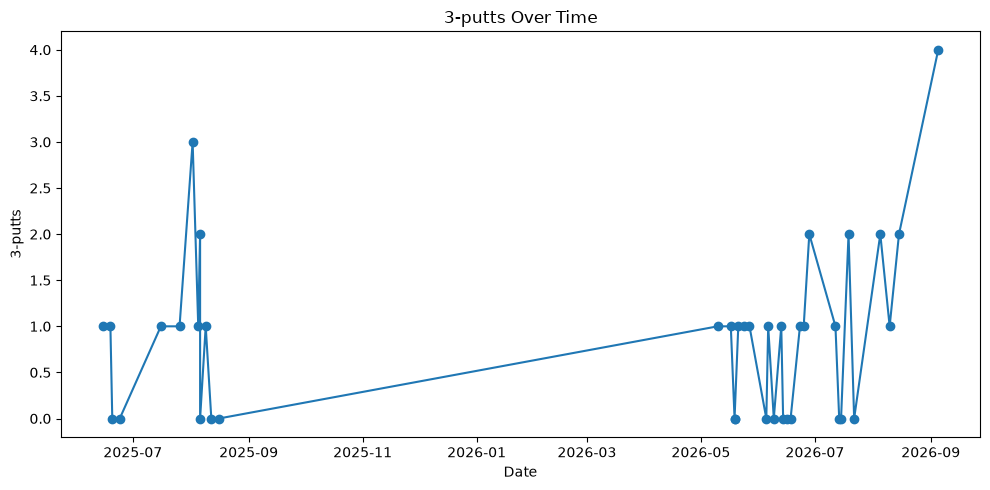

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(golfdatadf["Date"], golfdatadf["3-putt"], marker="o")

plt.xlabel("Date")
plt.ylabel("3-putts")
plt.title("3-putts Over Time")

plt.tight_layout()
plt.show()

All of these are very variable depending on the round. There is not a consisten trend to signify that I have improved with any of these. I will now move to compare all of these statistics in terms of the scoring differential.

### 2. GIR/Fairway/Up-and-down/3-putt/Birdies/Penalties vs Scoring Differential

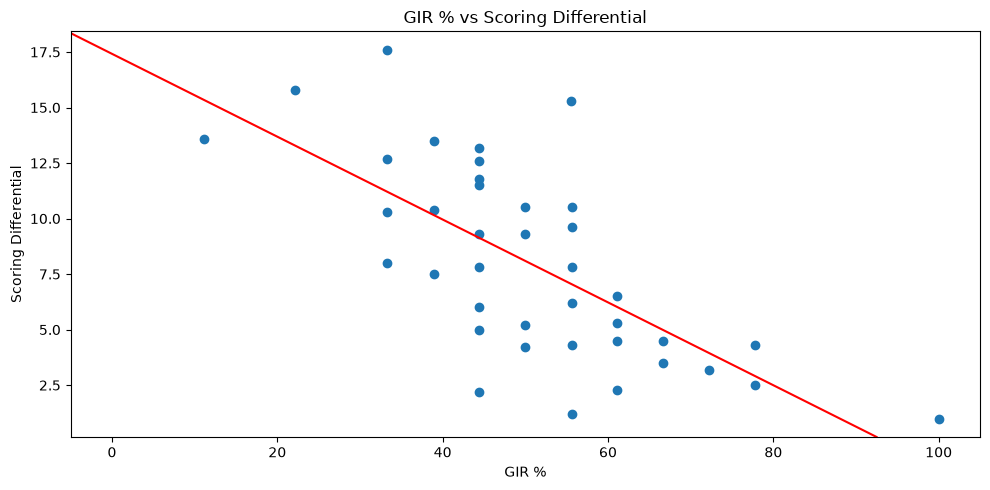

In [14]:
plt.figure(figsize=(10, 5))

m, b = np.polyfit(golfdatadf["GIR %"], golfdatadf["difference_round"], deg=1)
plt.scatter(golfdatadf["GIR %"], golfdatadf["difference_round"], marker="o")
plt.axline(xy1=(0, b), slope=m, color='red')

plt.ylabel("Scoring Differential")
plt.xlabel("GIR %")
plt.title("GIR % vs Scoring Differential")

plt.tight_layout()
plt.show()

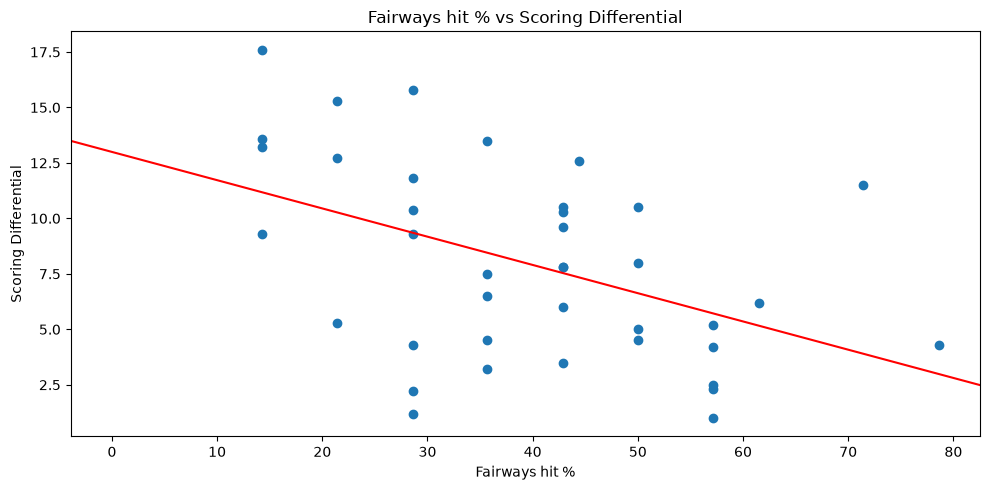

In [15]:
plt.figure(figsize=(10, 5))

m, b = np.polyfit(golfdatadf["Fairways hit %"], golfdatadf["difference_round"], deg=1)
plt.scatter(golfdatadf["Fairways hit %"], golfdatadf["difference_round"], marker="o")
plt.axline(xy1=(0, b), slope=m, color='red')

plt.ylabel("Scoring Differential")
plt.xlabel("Fairways hit %")
plt.title("Fairways hit % vs Scoring Differential")

plt.tight_layout()
plt.show()

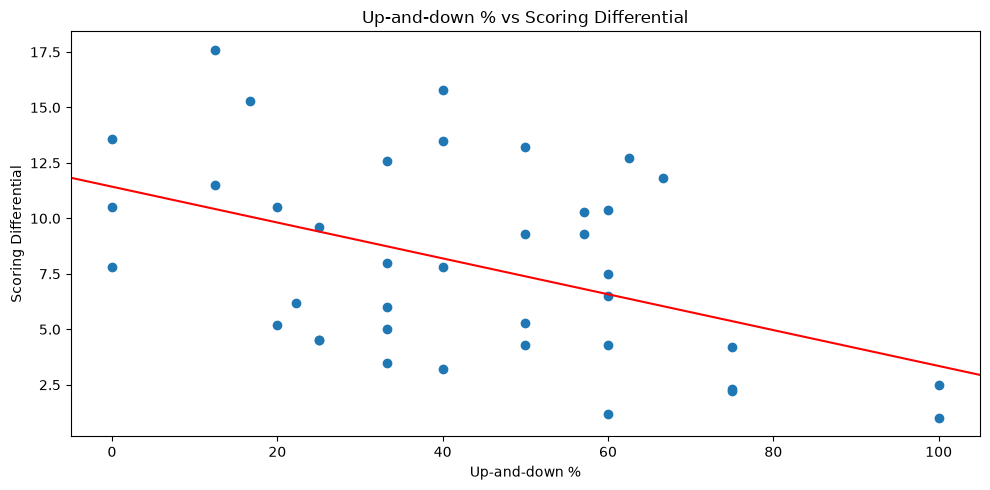

In [16]:
plt.figure(figsize=(10, 5))

m, b = np.polyfit(golfdatadf["Up-and-down %"], golfdatadf["difference_round"], deg=1)
plt.scatter(golfdatadf["Up-and-down %"], golfdatadf["difference_round"], marker="o")
plt.axline(xy1=(0, b), slope=m, color='red')

plt.ylabel("Scoring Differential")
plt.xlabel("Up-and-down %")
plt.title("Up-and-down % vs Scoring Differential")

plt.tight_layout()
plt.show()

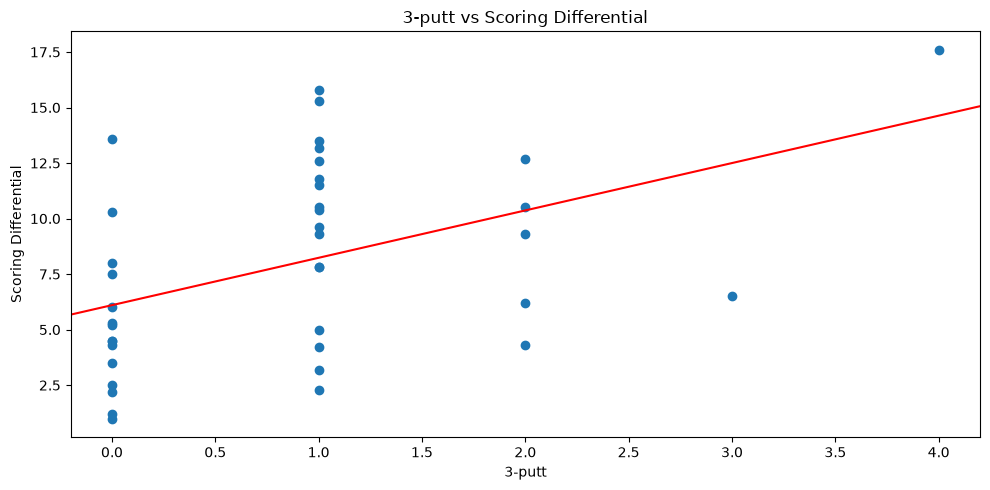

In [17]:
plt.figure(figsize=(10, 5))

m, b = np.polyfit(golfdatadf["3-putt"], golfdatadf["difference_round"], deg=1)
plt.scatter(golfdatadf["3-putt"], golfdatadf["difference_round"], marker="o")
plt.axline(xy1=(0, b), slope=m, color='red')

plt.ylabel("Scoring Differential")
plt.xlabel("3-putt")
plt.title("3-putt vs Scoring Differential")

plt.tight_layout()
plt.show()

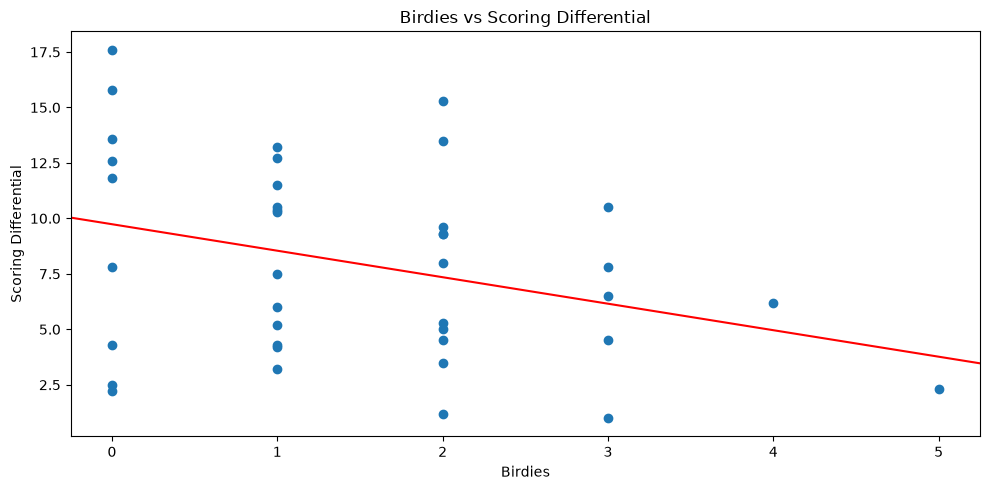

In [18]:
plt.figure(figsize=(10, 5))

m, b = np.polyfit(golfdatadf["Birdies"], golfdatadf["difference_round"], deg=1)
plt.scatter(golfdatadf["Birdies"], golfdatadf["difference_round"], marker="o")
plt.axline(xy1=(0, b), slope=m, color='red')

plt.ylabel("Scoring Differential")
plt.xlabel("Birdies")
plt.title("Birdies vs Scoring Differential")

plt.tight_layout()
plt.show()

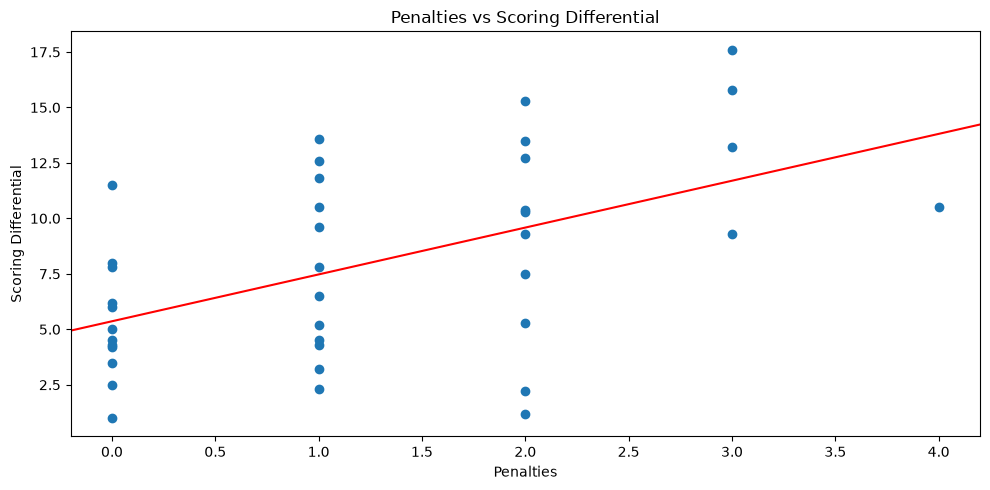

In [19]:
plt.figure(figsize=(10, 5))

m, b = np.polyfit(golfdatadf["Penalties"], golfdatadf["difference_round"], deg=1)
plt.scatter(golfdatadf["Penalties"], golfdatadf["difference_round"], marker="o")
plt.axline(xy1=(0, b), slope=m, color='red')

plt.ylabel("Scoring Differential")
plt.xlabel("Penalties")
plt.title("Penalties vs Scoring Differential")

plt.tight_layout()
plt.show()

The graphs show trends and patterns, especially the first three, which have percentages. They all show postive trends meaning, the more of that stat in the better direction, the better the scoring differential. GIR % seems to have the highest strength toward a greater trend, but also up-and-down %. These both mean that short game and approach holds a significant factor apart from the off-the-tee, which would be fairway %. We can double check this by creating a correlation matrix, and doing more advanced analytics. We will also compare these statistic to available public PGA golf, to see the greatest gaps I have.

## Correlation

In [36]:
metrics = [
    "difference_round",
    "Fairways hit %",
    "GIR %",
    "Putts_per_hole",
    "Up-and-down %",
    "Penalties",
    "3-putt",
    "Birdies"
]

correlation = golfdatadf[metrics].corr()
## GIR/Fairways/Birdies/Up-and-down, made absolute value for ease of information
correlation["difference_round"] = correlation["difference_round"].abs()
score_correlation = correlation["difference_round"].sort_values() 
score_correlation


Putts_per_hole      0.308513
Birdies             0.330115
3-putt              0.449148
Up-and-down %       0.459757
Fairways hit %      0.460747
Penalties           0.523932
GIR %               0.685023
difference_round    1.000000
Name: difference_round, dtype: float64

The highest correlation is GIR % meaning there is a high relationship of correlation between GIR % and scoring differential. Some notable things were that birdies and putts-per-hole did not have a significant correlation to scores, meaning that if I shrunk my putts down and had more birdies, my score wouldnt necessarily change as much overall. GIR % seems to be the highest and the cause of score variability. This would mean that focusing on maintaining a high GIR % would be the key factor in improving my golf game.

I wanted to predict how these high correlation variables can affect my score if they were higher.

## Linear Regression

To further examine the relationship between GIR and Scoring differential, I used linear regression to model how changes in GIR are associated with changes in score. Since GIR had the strongest correlation with score, I selected it as the predictor variable. The regression model will provide a fitted equation used to predict score.

In [ ]:
from sklearn.linear_model import LinearRegression

## Regression of GIR/Score differential
girlin = golfdatadf[["GIR %"]]
scordifflin = golfdatadf["difference_round"]

model = LinearRegression()
model.fit(girlin, scordifflin)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

r2 = model.score(girlin, scordifflin)
print("R-squared:", r2)

Intercept: 17.418117307981124
Clope: -0.18649577004554288
R-squared: 0.4692564269335958


Interpreting these numbers, the slope of -0.18 means that with an extra 1 percentage of GIR% I lose approximately -0.18 in score differential. This is a positive result, meaning that an extra 10% in GIR = -1.864 strokes in score differential. The R-squared means that 47% variation in score differential is explained by the GIR, something that I can work to change for my golf game.

In [ ]:
## Regression of Penalties/Score differential
penlin = golfdatadf[["Penalties"]]
scordifflin = golfdatadf["difference_round"]

model = LinearRegression()
model.fit(penlin, scordifflin)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

r2 = model.score(penlin, scordifflin)
print("R-squared:", r2)

Intercept: 5.363013698630137
Slope: 2.1113013698630145
R-squared: 0.27450435382258465


Interpreting these numbers, the slope of 2.11 means that with an extra 1 penalty I gain approximately 2.11 strokes in score differential. This is a negative result, highlighting that penalties cost a lot more to my scoring then the generic stroke effect. Penalties put me in worse positions and can help reduce my scoring differential. 27% of the variation in scoring differential can be explained by penalties.

I will now combine these into two, creating a model to project a new line. I will then do some predictive hypotheticals comparing PGA averages to the model.

In [ ]:
comblin = golfdatadf[["GIR %", "Penalties"]]
scordifflin = golfdatadf["difference_round"]

model = LinearRegression()
model.fit(comblin, scordifflin)

print("Intercept:", model.intercept_)
print("GIR Slope:", model.coef_[0])
print("Penalties Slope:", model.coef_[1])

r2 = model.score(comblin, scordifflin)
print("R-squared:", r2)

Intercept: 14.27104257965994
GIR Slope: -0.15469055874588677
Penalties Slope: 1.2466500155578804
R-squared: 0.5513141476654242


Interpreting these numbers, a basis linear model was defined:

Score Differential = 14.2710 - 0.1547(GIR %) + 1.2467(Penalties)
With penalties constant, a GIR% increase by 1 results in .155 fewer strokes and with penalties holding GIR% constant, that is associated with a 1.24 worse scoring differential. With the R-squared, GIR% and Penalties explain 55% of the variation in the scoring differential. Since this was the highest R-squared, the combination is the strongest predictor to scoring differential and can help predict what improvements will mean.

### Pro - Comparison

In [60]:
progir = 68
propenalties = 0.5

GIRdifference = golfdatadf["GIR %"].mean() - progir
PENdifference = golfdatadf["Penalties"].mean() - propenalties

df = [GIRdifference, PENdifference]

df

[np.float64(-17.293333333333337), np.float64(0.7307692307692308)]

These numbers mean, that on average, I have -17.29 percentage points of GIR and about .73 more penalties than pros, which is very far off, but taking the linear model, we can calculate average score differential using pros and compare it to pro differential to see if just working on GIR and penalties makes a significant difference.

In [63]:
predictscorediffpro = 14.271 - 0.1547*(progir) + 1.24665*(propenalties)
actualscorediffpro = -2.35

predictscorediffpro

predictscorediffpro - actualscorediffpro

6.724725000000001

Using the predicted scoring differential for pro level GIR vs actual scoring diffrential, I see I am still 6.7 strokes off, meaning that other factors of the game still go into improvement apart from my GIR and penalties.

### Conclusions

GIR was the strongest individual predictor of score differential. This means that by improving my GIR I can lower my scoring differential the fastest. I can do this by focusing on my iron shots and precision hitting. Some training drills for this could be green hitting where I pick a target and focus on hitting the target. 

Penalties were also meaningfully associated with worse scoring. This means that by reducing penalties I can also drop my score drastically. This can be achieved by using smart analytics and risk reduction on the golf course, where I stay away from risk areas.

Overall, I learned a lot about how my golf game works through analysis and linear regression. I know what factors to work on for the best results and I can get lessons to increase my productivity. In the future I would build this into an app, and come in with more data, as variation may be lesser. Golf rounds are hard to come by which is why individual data is small. I would love to do this with other people's rounds however, and I hope to improve my golf scores more and more.